# Level 4: Data Analysis & Visualization

**Project:** HydroSense-Kenya  
**Level:** 4 of 6

---

## Objective

The purpose of this notebook is to explore and visualize the HydroSense datasets.

Using graphical and statistical analysis, we aim to:

1. Understand weather patterns.
2. Study soil moisture behaviour.
3. Investigate irrigation performance.
4. Compare crop zones.
5. Discover trends useful for intelligent irrigation scheduling.

The datasets used in this notebook were cleaned and validated during Level 1.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

plt.style.use("default")

weather = pd.read_csv("../data/processed/weather_daily_cleaned.csv")
soil = pd.read_csv("../data/processed/soil_sensor_data_cleaned.csv")
crop = pd.read_csv("../data/processed/crop_zone_parameters_cleaned.csv")

weather["date"] = pd.to_datetime(weather["date"])
soil["timestamp"] = pd.to_datetime(soil["timestamp"])

print("Weather:", weather.shape)
print("Soil:", soil.shape)
print("Crop:", crop.shape)

Weather: (28, 6)
Soil: (89, 7)
Crop: (3, 7)


## Dataset Overview

Before performing analysis, it is important to understand the size and structure of the available data.

The weather dataset contains daily environmental conditions.

The soil dataset contains sensor readings collected from different crop zones.

The crop dataset contains configuration parameters used by HydroSense when making irrigation decisions.

A quick overview helps verify that the datasets loaded successfully.

In [2]:
weather.head()

,date,rainfall_mm,temperature_c,humidity_pct,wind_speed_mps,solar_index
0,2026-03-01,3.2,23.8,69.7,2.28,0.78
1,2026-03-02,2.2,25.9,62.0,1.62,0.71
2,2026-03-03,3.0,26.8,64.4,2.11,0.75
3,2026-03-04,1.6,27.0,64.6,2.09,0.58
4,2026-03-05,23.7,26.6,61.0,1.36,0.62


In [3]:
soil.head()

,timestamp,zone_id,soil_moisture_pct,tank_level_liters,pump_flow_lpm,pump_power_watts,sensor_status
0,2026-03-01 12:00:00,Zone_A,33.2,4829,18.8,437,OK
1,2026-03-01 12:00:00,Zone_B,34.7,4728,22.1,461,OK
2,2026-03-01 12:00:00,Zone_C,28.2,4515,25.7,490,OK
3,2026-03-02 12:00:00,Zone_A,36.1,4757,16.6,411,OK
4,2026-03-02 12:00:00,Zone_B,32.0,4645,20.4,445,OK


In [4]:
crop.head()

,zone_id,crop_type,area_m2,min_moisture_pct,target_moisture_pct,field_capacity_pct,drainage_coefficient
0,Zone_A,tomato,120,22,33,41,0.18
1,Zone_B,kale,90,24,35,43,0.15
2,Zone_C,maize,180,20,31,40,0.22


## Descriptive Statistics

Descriptive statistics provide a summary of the dataset.

Measures such as:

- Mean
- Minimum
- Maximum
- Standard Deviation

help us understand the distribution of measurements before visualization.

In [5]:
weather.describe()

,date,rainfall_mm,temperature_c,humidity_pct,wind_speed_mps,solar_index
count,28,28.000000,28.000000,28.000000,28.000000,28.000000
mean,2026-03-15 08:34:17.142857216,8.851108,24.560714,65.678571,2.091786,0.675357
min,2026-03-01 00:00:00,0.000000,21.400000,56.300000,1.140000,0.490000
25%,2026-03-07 18:00:00,0.850000,22.950000,63.475000,1.642500,0.587500
50%,2026-03-15 12:00:00,3.100000,24.700000,64.850000,2.115000,0.695000
75%,2026-03-23 06:00:00,8.573276,26.375000,68.375000,2.417500,0.760000
max,2026-03-30 00:00:00,85.000000,27.400000,74.600000,3.100000,0.800000
std,NaN,16.590793,1.856388,4.159270,0.527573,0.095897


In [6]:
soil.describe()

,timestamp,soil_moisture_pct,tank_level_liters,pump_flow_lpm,pump_power_watts
count,89,89.000000,89.000000,89.000000,89.000000
mean,2026-03-16 00:24:16.179775232,27.542697,4124.303371,21.853933,458.662921
min,2026-03-01 12:00:00,8.500000,3369.000000,15.200000,394.000000
25%,2026-03-08 12:00:00,25.000000,3836.000000,18.800000,434.000000
50%,2026-03-16 12:00:00,27.700000,4137.000000,21.900000,461.000000
75%,2026-03-23 12:00:00,30.600000,4423.000000,25.000000,488.000000
max,2026-03-30 12:00:00,36.100000,4836.000000,28.800000,523.000000
std,NaN,4.540196,374.899271,3.510279,31.477966


## Weather Analysis

Weather conditions directly influence irrigation demand.

Key variables include:

- Rainfall
- Temperature
- Humidity
- Wind Speed
- Solar Radiation

Understanding these variables helps estimate crop water requirements. 

---

### Rainfall 

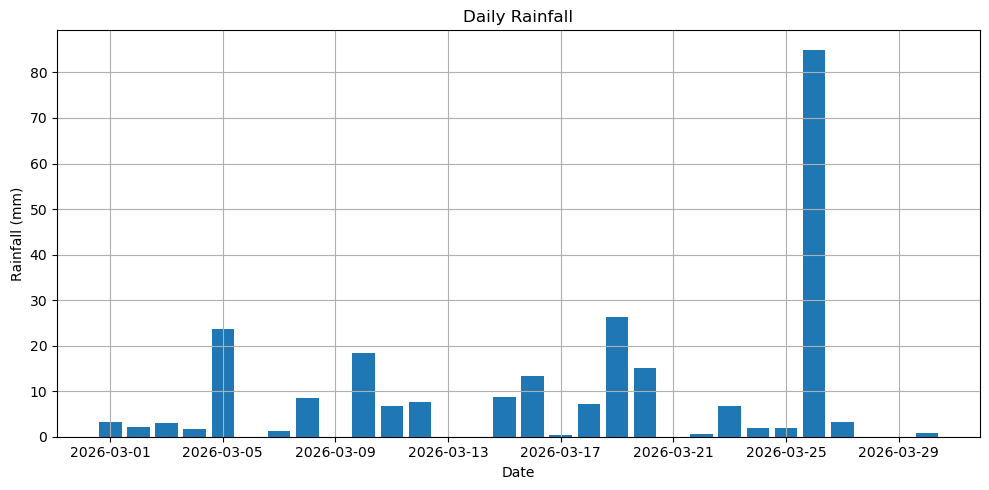

In [7]:
plt.figure(figsize=(10,5))

plt.bar(
    weather["date"],
    weather["rainfall_mm"]
)

plt.title("Daily Rainfall")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.grid(True)

plt.tight_layout()
plt.show()

#### Interpretation

Rainfall is one of the most important variables in irrigation planning. Periods of high rainfall naturally reduce irrigation demand, while prolonged dry periods require supplemental watering. HydroSense uses rainfall information to avoid unnecessary irrigation and conserve water. 

---

### Temperature

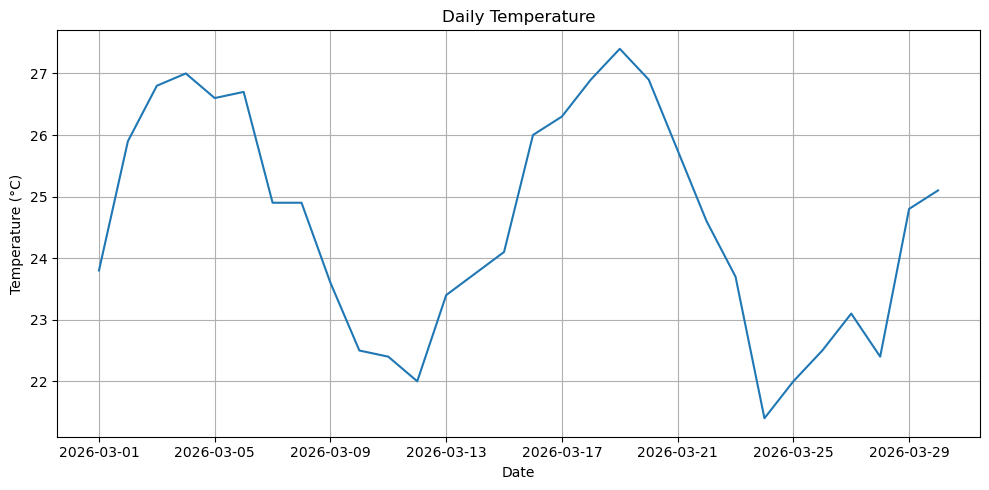

In [8]:
plt.figure(figsize=(10,5))

plt.plot(
    weather["date"],
    weather["temperature_c"]
)

plt.title("Daily Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)

plt.tight_layout()
plt.show()

#### Interpretation

Temperature strongly affects evapotranspiration. Higher temperatures generally increase water loss from both soil and plants. As temperature rises, irrigation demand typically increases. 

---

### Humidity 

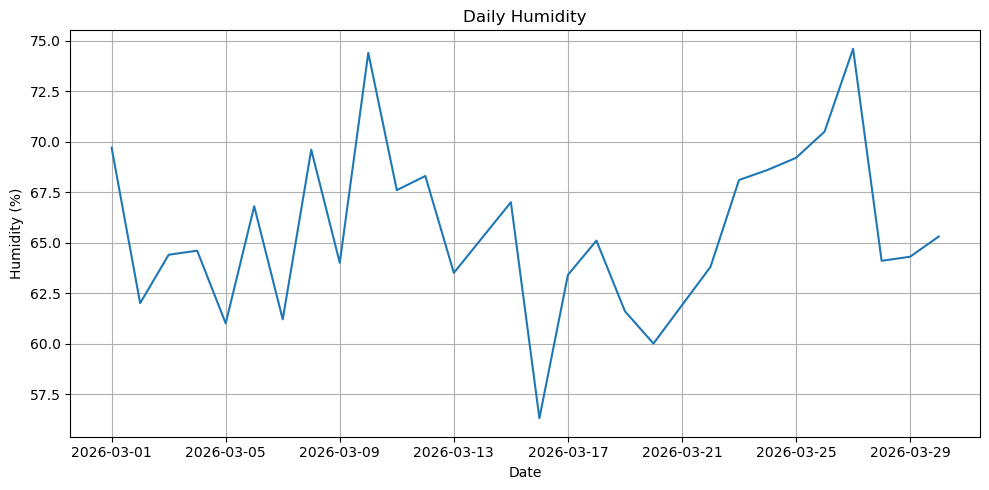

In [9]:
plt.figure(figsize=(10,5))

plt.plot(
    weather["date"],
    weather["humidity_pct"]
)

plt.title("Daily Humidity")
plt.xlabel("Date")
plt.ylabel("Humidity (%)")
plt.grid(True)

plt.tight_layout()
plt.show()

#### Interpretation

Humidity influences the rate at which water evaporates from the soil surface. Lower humidity often corresponds to faster drying rates and increased irrigation needs. Monitoring humidity improves irrigation accuracy. 

---

## Soil Moisture Analysis

Soil moisture is the core variable monitored by HydroSense. The system continuously evaluates moisture levels and determines whether irrigation is required. Visualizing moisture trends allows us to assess crop conditions across zones. 

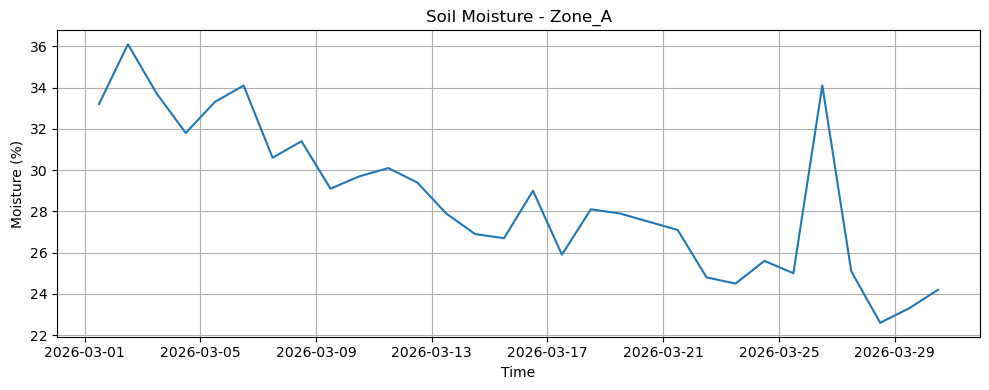

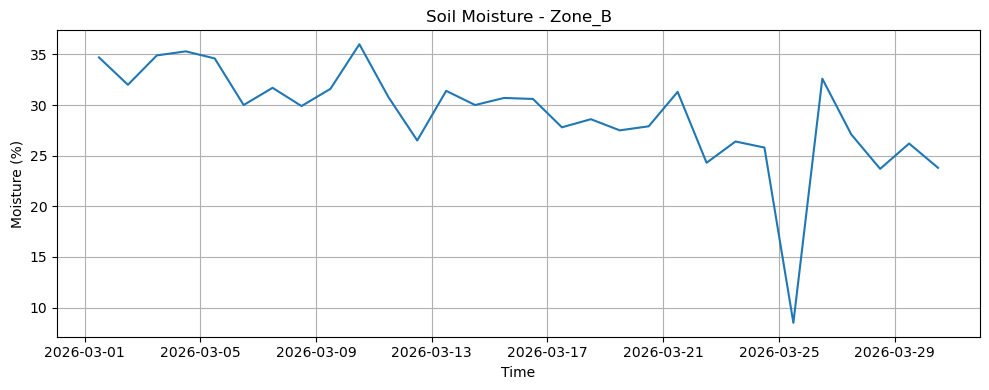

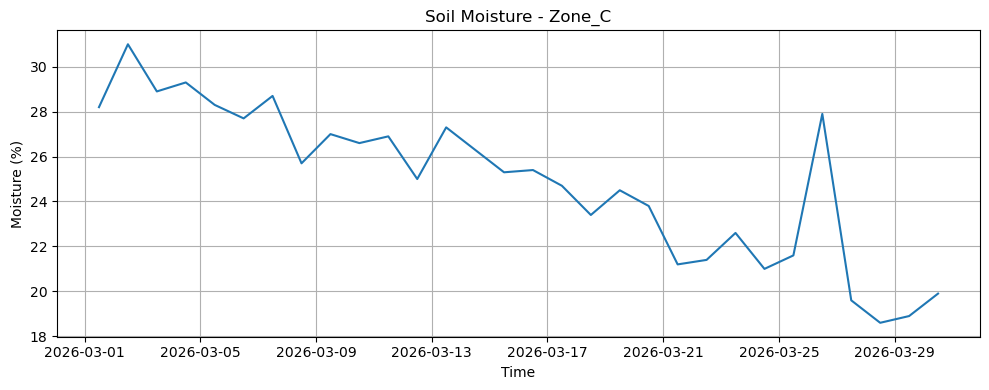

In [10]:
zones = soil["zone_id"].unique()

for zone in zones:
    
    subset = soil[
        soil["zone_id"] == zone
    ]
    
    plt.figure(figsize=(10,4))
    
    plt.plot(
        subset["timestamp"],
        subset["soil_moisture_pct"]
    )
    
    plt.title(f"Soil Moisture - {zone}")
    plt.xlabel("Time")
    plt.ylabel("Moisture (%)")
    
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#### Interpretation

Fluctuations in soil moisture reflect the interaction between:

- Rainfall
- Irrigation
- Evapotranspiration
- Drainage

Maintaining moisture near the target level helps maximize crop growth while minimizing water wastage. 

---

## Pump Performance Analysis

Efficient irrigation depends on reliable pumping systems. 

Pump flow rate and power consumption influence:

- Water delivery efficiency
- Energy consumption
- Operational cost

The following visualizations examine pump behaviour.

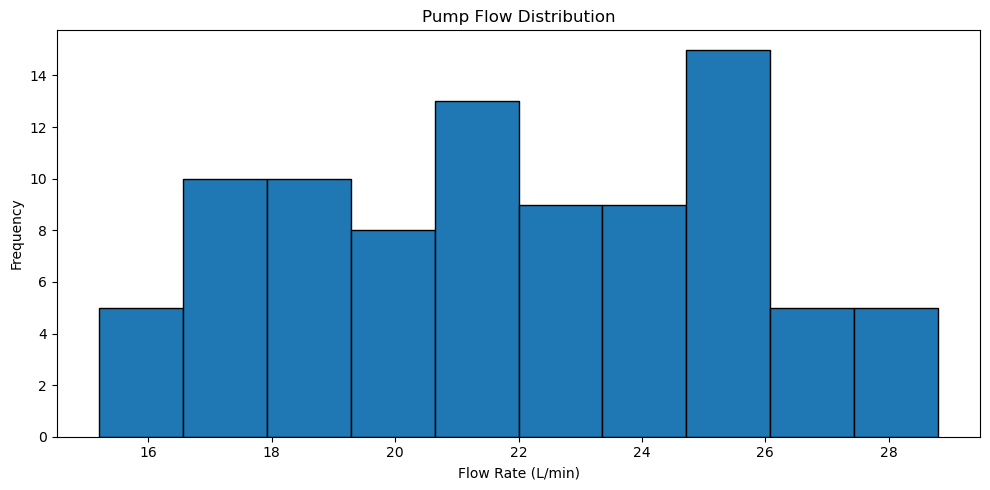

In [11]:
plt.figure(figsize=(10,5))

plt.hist(
    soil["pump_flow_lpm"],
    bins=10,
    edgecolor="black"
)

plt.title("Pump Flow Distribution")
plt.xlabel("Flow Rate (L/min)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

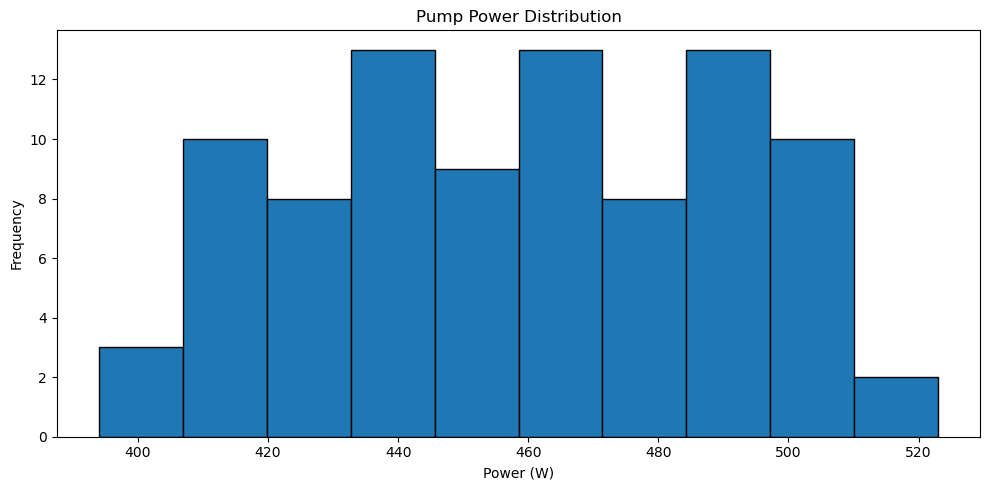

In [12]:
plt.figure(figsize=(10,5))

plt.hist(
    soil["pump_power_watts"],
    bins=10,
    edgecolor="black"
)

plt.title("Pump Power Distribution")
plt.xlabel("Power (W)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Interpretation

A stable distribution indicates consistent pump operation.

Significant variation may suggest:

- Equipment wear
- Sensor errors
- Operational inefficiencies

Such insights can support predictive maintenance strategies.

---

## Crop Zone Comparison

Different crop zones may have different:

- Moisture targets
- Field capacities
- Drainage characteristics

Comparing zones helps determine whether irrigation policies should be adjusted for individual crops.

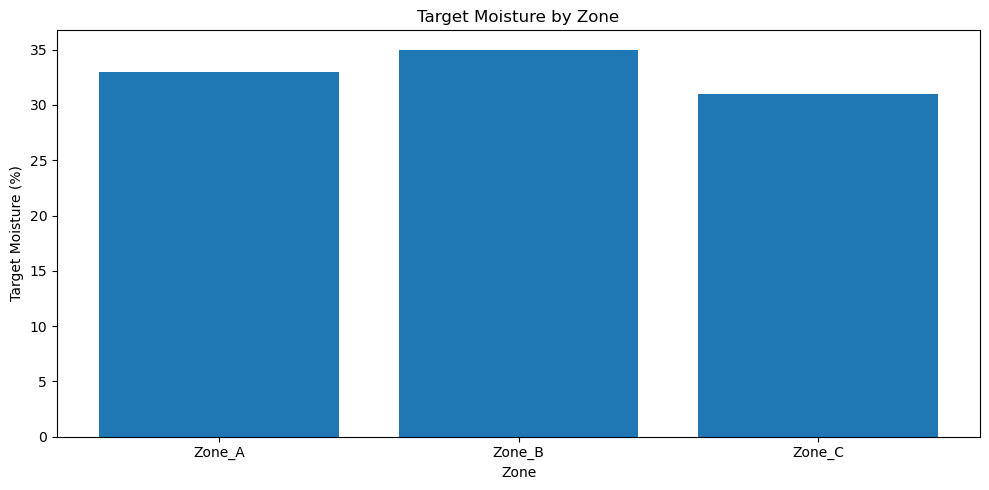

In [13]:
plt.figure(figsize=(10,5))

plt.bar(
    crop["zone_id"],
    crop["target_moisture_pct"]
)

plt.title("Target Moisture by Zone")
plt.xlabel("Zone")
plt.ylabel("Target Moisture (%)")

plt.tight_layout()
plt.show()

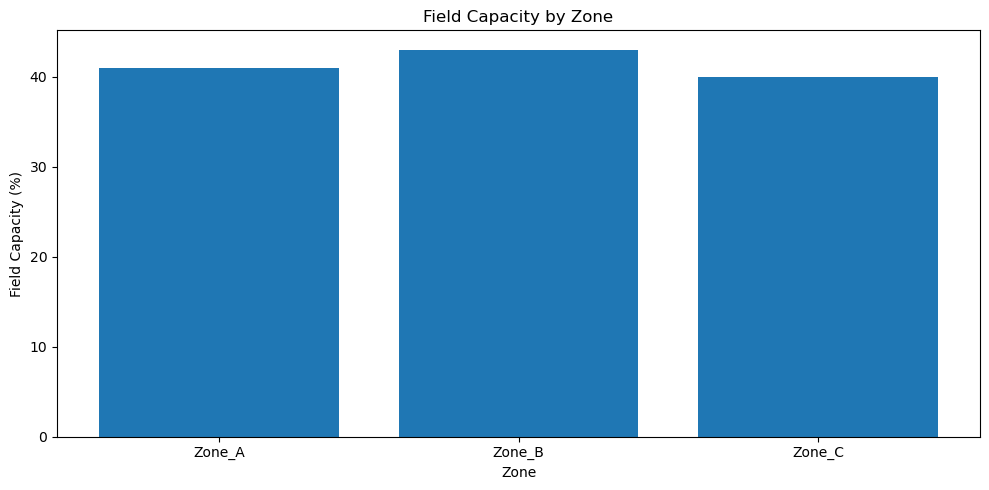

In [14]:
plt.figure(figsize=(10,5))

plt.bar(
    crop["zone_id"],
    crop["field_capacity_pct"]
)

plt.title("Field Capacity by Zone")
plt.xlabel("Zone")
plt.ylabel("Field Capacity (%)")

plt.tight_layout()
plt.show()

### Interpretation

Zones with larger target moisture values require more frequent irrigation. Field capacity provides an upper limit for safe water storage in the soil. Exceeding field capacity can lead to runoff and nutrient loss. 

---

## Correlation Analysis

Correlation analysis measures relationships between variables. Strong relationships may reveal useful predictors for irrigation demand.

For example:

- Temperature may influence soil moisture.
- Rainfall may influence tank usage.
- Humidity may influence evapotranspiration.

In [15]:
weather.corr(numeric_only=True)

,rainfall_mm,temperature_c,humidity_pct,wind_speed_mps,solar_index
rainfall_mm,1.000000,-0.075140,0.140789,-0.113661,-0.149738
temperature_c,-0.075140,1.000000,-0.624990,0.057064,-0.058276
humidity_pct,0.140789,-0.624990,1.000000,0.276371,-0.075473
wind_speed_mps,-0.113661,0.057064,0.276371,1.000000,0.040360
solar_index,-0.149738,-0.058276,-0.075473,0.040360,1.000000


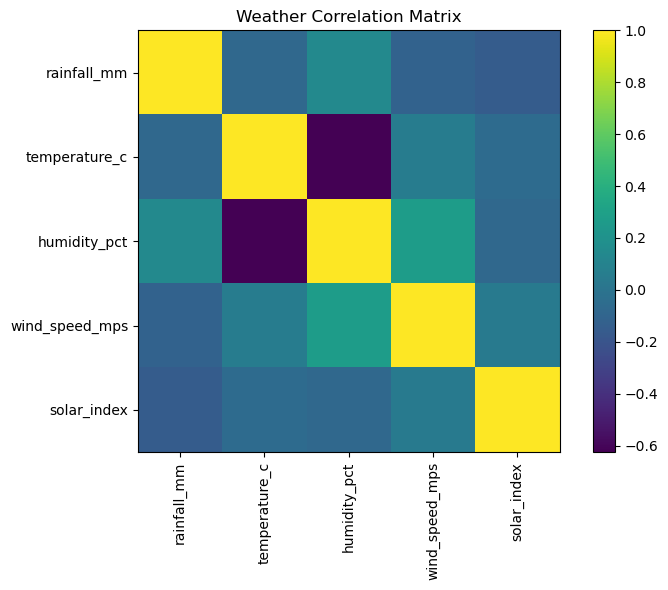

In [16]:
corr = weather.corr(numeric_only=True)

plt.figure(figsize=(8,6))

plt.imshow(corr)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Weather Correlation Matrix")

plt.tight_layout()
plt.show()

### Interpretation

Correlation values close to:

- +1 indicate a strong positive relationship.
- -1 indicate a strong negative relationship.
- 0 indicate little or no linear relationship.

These relationships can guide the selection of variables used in predictive irrigation models. 

---

## Key Findings

The analysis reveals several important observations:

1. Weather conditions vary over time and significantly influence irrigation demand.

2. Soil moisture levels fluctuate across crop zones, highlighting the importance of zone-specific irrigation strategies.

3. Pump behaviour appears measurable and can be monitored for efficiency assessment.

4. Crop zones possess different moisture requirements and should not be managed identically.

5. Correlation analysis suggests that environmental variables contain useful predictive information.

These findings support the development of intelligent irrigation scheduling systems. 

---

# Conclusion

This notebook explored the HydroSense Kenya datasets using statistical and graphical techniques.

The visualizations provided insight into:

- Weather behaviour
- Soil moisture dynamics
- Pump operation
- Crop zone characteristics

These analyses form the foundation for advanced simulation, optimization and decision-support components implemented in later stages of the HydroSense project.